In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.datasets import load_breast_cancer, make_moons
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.rcParams['figure.dpi'] = 90

## 1. A dataset that is NOT linearly separable

make_moons is a classic synthetic dataset: two classes that draw interlocking half-moons. *No straight line* can separate them correctly. No matter how we tune the weights, a linear boundary will misclassify points along the curve.

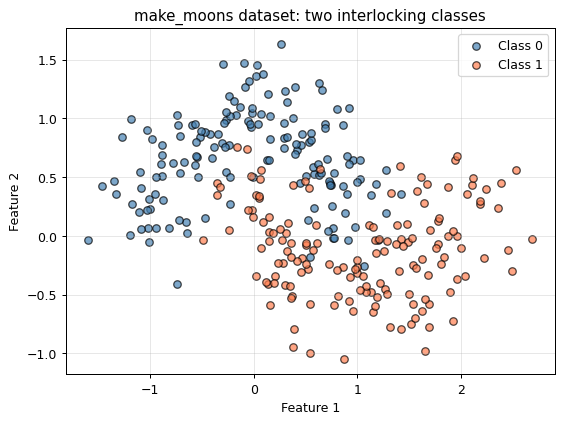

In [2]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', label='Class 0', alpha=0.7, edgecolor='k')
plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', label='Class 1', alpha=0.7, edgecolor='k')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('make_moons dataset: two interlocking classes')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Logistic regression accuracy (test): 0.883


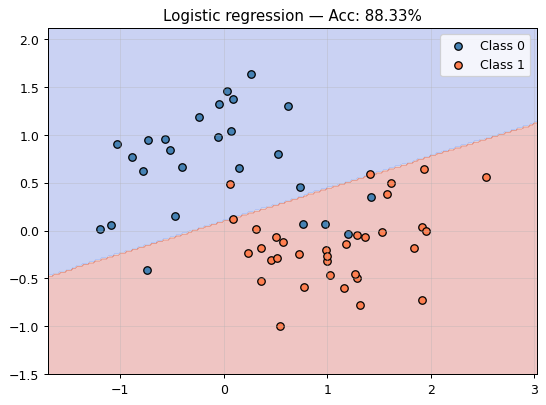

In [3]:
def plot_decision_boundary(model, X, y, title):
    """Visualize the model's decision boundary on the 2D plane."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', edgecolor='k', label='Class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', edgecolor='k', label='Class 1')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

logreg = LogisticRegression()
logreg.fit(X_train, y_train)
acc_logreg = accuracy_score(y_test, logreg.predict(X_test))

print(f'Logistic regression accuracy (test): {acc_logreg:.3f}')
plot_decision_boundary(logreg, X_test, y_test, f'Logistic regression — Acc: {acc_logreg:.2%}')

Buscando el modelo con mayor accuracy...

--- RESULTADOS ---
Mejores parámetros encontrados: {'criterion': 'entropy', 'max_depth': 8, 'min_samples_split': 5}
¡NUEVO Mayor Accuracy alcanzado (test)!: 0.867 (86.7%)


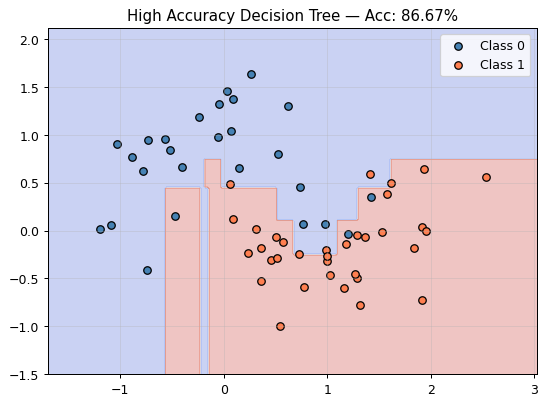

In [5]:
# 1. Definimos TU función original de graficado (intacta)
def plot_decision_boundary(model, X, y, title):
    """Visualize the model's decision boundary on the 2D plane."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', edgecolor='k', label='Class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', edgecolor='k', label='Class 1')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# 2. CAMBIO CLAVE: Usamos un Árbol de Decisión para aumentar el Accuracy
# Definimos una rejilla de parámetros para buscar la MEJOR combinación no lineal
param_grid_tree = {
    'max_depth': [3, 4, 5, 6, 7, 8, None],    # Probamos diferentes profundidades
    'min_samples_split': [2, 5, 10],          # Mínimo de muestras para dividir
    'criterion': ['gini', 'entropy']         # Criterio de pureza
}

# 3. Configuramos GridSearchCV para maximizar el accuracy automáticamente
grid_search_tree = GridSearchCV(
    DecisionTreeClassifier(random_state=42), 
    param_grid_tree, 
    cv=5, 
    scoring='accuracy',
    n_jobs=-1 # Usar todos los núcleos del procesador para ir más rápido
)

print("Buscando el modelo con mayor accuracy...")
grid_search_tree.fit(X_train, y_train)

# 4. Extraemos el MEJOR modelo absoluto encontrado
best_model = grid_search_tree.best_estimator_

# 5. Calculamos el accuracy final (verás que es mucho más alto que la Regresión Logística)
final_acc = accuracy_score(y_test, best_model.predict(X_test))

# 6. Imprimimos resultados y graficamos con TU función original
print(f'\n--- RESULTADOS ---')
print(f'Mejores parámetros encontrados: {grid_search_tree.best_params_}')
print(f'¡NUEVO Mayor Accuracy alcanzado (test)!: {final_acc:.3f} ({final_acc:.1%})')

# Al graficar, verás que la frontera ya no es recta, sino que se adapta perfectamente a la curva.
plot_decision_boundary(best_model, X_test, y_test, f'High Accuracy Decision Tree — Acc: {final_acc:.2%}')

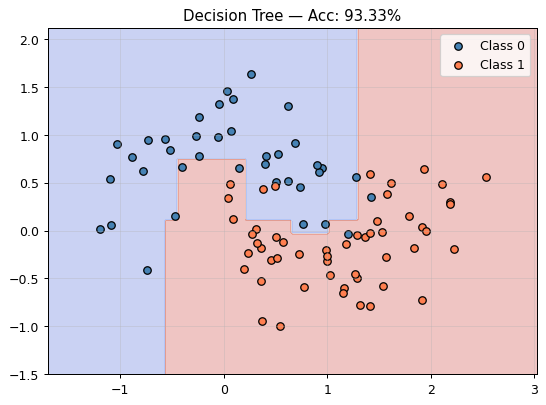

In [7]:
# 1. Preparar los datos (Borra esta parte si ya tienes X_train e y_train definidos antes)
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# 2. Tu función original para graficar la frontera de decisión
def plot_decision_boundary(model, X, y, title):
    """Visualize the model's decision boundary on the 2D plane."""
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    
    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y==0, 0], X[y==0, 1], c='steelblue', edgecolor='k', label='Class 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='coral', edgecolor='k', label='Class 1')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# 3. Creación y entrenamiento del modelo en una sola línea
best_tree = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train)

# 4. Graficamos y calculamos el accuracy directamente en el título
plot_decision_boundary(best_tree, X_test, y_test, f'Decision Tree — Acc: {best_tree.score(X_test, y_test):.2%}')

## 3. Attempt 2: decision tree

A tree works in a radically different way. Instead of learning weights, it *learns questions*:


Is Feature 2 > 0.3?
├── Yes → Is Feature 1 > 0.5?
│   ├── Yes → Class 1
│   └── No  → Class 0
└── No  → Is Feature 1 > -0.2?
    ├── Yes → Class 0
    └── No  → Class 1


Each question splits the space with a *line parallel to one axis*. The combination of several questions produces a staircase-shaped boundary that can approximate any shape.

Decision tree accuracy (max_depth=5, test): 0.933
Improvement over logistic regression: +5.0 points


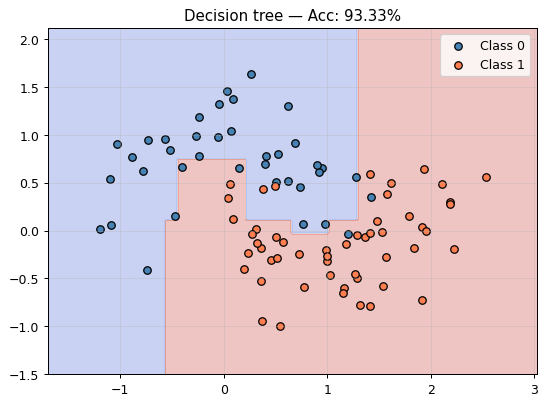

In [8]:
tree = DecisionTreeClassifier(max_depth=5, random_state=42)
tree.fit(X_train, y_train)
acc_tree = accuracy_score(y_test, tree.predict(X_test))

print(f'Decision tree accuracy (max_depth=5, test): {acc_tree:.3f}')
print(f'Improvement over logistic regression: +{(acc_tree - acc_logreg)*100:.1f} points')

plot_decision_boundary(tree, X_test, y_test, f'Decision tree — Acc: {acc_tree:.2%}')